# Кластеризация данных сотрудников

Это набор данных предоставляет 10000 записей о сотрудниках.Данный набор предназначен для анализа кадровых тенденций, эффективности сотрудников, производительности и внутренних взаимодействиях в компании.


# Описание набора данных

База данных сотрудников содержит персональную информацию, контактные данные и сведения о должностях 10 000 работников.
Расшифровка каждого атрибута:
- Index - персональный индекс сотрудника
- First name - Имя сотрудника
- Last name - Фамилия сотрудника
- Sex - Пол сотрудника
- Email - Почта сотрудника
- Phone - Телефон сотрудника
- Date of birth - День рождения сотрудника
- Job Title - Должность

# Загрузка данных

## Подключение необходимых библиотек и функций

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%pip install openpyxl
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Обзор датасета

In [2]:
df = pd.read_csv("Employee 1000x.csv")

In [3]:
df

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,17-08-21,"Editor, commissioning"
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,28-06-69,Broadcast engineer
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,25-09-15,Industrial buyer
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,27-07-78,Multimedia specialist
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,17-11-89,Planning and development surveyor
...,...,...,...,...,...,...,...,...
9995,9996,Tina,Sherman,Male,bartlettcolleen@example.org,(455)476-4044x5755,28-07-74,"Scientist, physiological"
9996,9997,Earl,Jennings,Female,andreabenton@example.com,009.056.6505,20-08-32,Warehouse manager
9997,9998,Ellen,Dominguez,Female,michaelayoder@example.net,409-428-4297x469,06-06-66,Lawyer
9998,9999,Emma,Clark,Male,pstrickland@example.com,849-868-8653,09-05-07,Accounting technician


# Разведочный анализ

## Общая информация

In [4]:
df.shape

(10000, 8)

Датасет хранит в себе 10000 записей и 8 столбцов.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Index          10000 non-null  int64 
 1   First Name     10000 non-null  object
 2   Last Name      10000 non-null  object
 3   Sex            10000 non-null  object
 4   Email          10000 non-null  object
 5   Phone          10000 non-null  object
 6   Date of birth  10000 non-null  object
 7   Job Title      10000 non-null  object
dtypes: int64(1), object(7)
memory usage: 625.1+ KB


Датасет полностью заполнен, содержит 8 колонок и 10 тысяч записей. Типы данных: одна колонка числовая, а остальные — текстовые.

In [6]:
df.describe(include = "O")

,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
count,10000,10000,10000,10000,10000,10000,10000
unique,690,1000,2,9936,9992,8646,639
top,Martin,Velazquez,Female,bnorton@example.net,-10092,19-01-11,Film/video editor
freq,28,22,5074,3,2,4,30


Этот набор не содержит пропуски. Однако в номерах телефона присутствуют аномалии.

In [7]:
print(df.duplicated().sum())

0


Дубликаты не найдены.

C:\Users\User\AppData\Local\Temp\ipykernel_2624\1000024741.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='viridis')


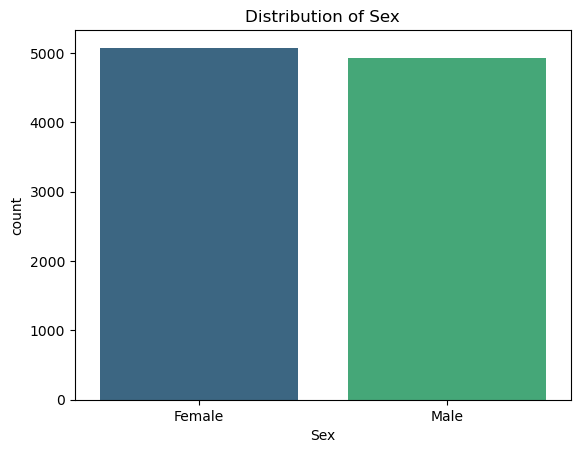

In [8]:
sns.countplot(data=df, x='Sex', palette='viridis')
plt.title('Distribution of Sex')
plt.show()

В компании женщин немного больше,чем мужчин

In [9]:
df["Job Title"].value_counts()

Job Title
Film/video editor           30
Wellsite geologist          28
Medical secretary           28
Exhibition designer         27
Probation officer           27
                            ..
Waste management officer     7
Press sub                    7
Chief Financial Officer      5
Holiday representative       5
Theatre director             5
Name: count, Length: 639, dtype: int64

более популярная должность это видеоредактор. Но нельзя сказать,что она распространена в компании т.к. записей всего 10000.

In [10]:
df["Date of birth"] = pd.to_datetime(df["Date of birth"],format = "%d-%m-%y",errors = "coerce")

In [11]:
df["Year"] = df["Date of birth"].dt.year
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Year
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",2021
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,1969
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,2015
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,1978
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,1989


Исправили формат дня рождения и вывели год в отдельный столбец

In [12]:
df["Age"] = 2026 - df["Year"]

In [13]:
df["Age"]

0        5
1       57
2       11
3       48
4       37
        ..
9995    52
9996    -6
9997   -40
9998    19
9999    -9
Name: Age, Length: 10000, dtype: int32

Мы четко увидели аномалии в возрасте.Попытаемся исправить их

In [14]:
from pandas.tseries.offsets import DateOffset

In [15]:
df["Original date"] = df["Date of birth"]
df.loc[df["Age"] < 0, "Date of birth"] -= DateOffset(years = 100)
df["Update Age"] = 2025 - df["Date of birth"].dt.year

In [16]:
df.loc[df["Age"]< 0]

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Year,Age,Original date,Update Age
14,15,Clayton,Erickson,Male,nterry@example.net,990-374-0521x33156,1959-02-07,Paediatric nurse,2059,-33,2059-02-07,66
19,20,Jon,Wagner,Female,meagan99@example.org,001-940-671-0693x345,1934-01-06,"Engineer, aeronautical",2034,-8,2034-01-06,91
20,21,Glen,Calderon,Male,randystephenson@example.net,4890361487,1944-09-16,"Research officer, government",2044,-18,2044-09-16,81
21,22,Marco,Sharp,Male,cmcclure@example.net,074-415-1149,1944-04-09,Retail buyer,2044,-18,2044-04-09,81
24,25,Meghan,Blanchard,Male,smejia@example.org,+1-188-201-3028x13440,1927-08-24,Occupational therapist,2027,-1,2027-08-24,98
...,...,...,...,...,...,...,...,...,...,...,...,...
9992,9993,Marvin,Davenport,Female,jade07@example.net,400-198-5125,1929-10-18,Restaurant manager,2029,-3,2029-10-18,96
9993,9994,Eddie,Clements,Female,chelsey82@example.net,855.007.8490x535,1938-06-15,Control and instrumentation engineer,2038,-12,2038-06-15,87
9996,9997,Earl,Jennings,Female,andreabenton@example.com,009.056.6505,1932-08-20,Warehouse manager,2032,-6,2032-08-20,93
9997,9998,Ellen,Dominguez,Female,michaelayoder@example.net,409-428-4297x469,1966-06-06,Lawyer,2066,-40,2066-06-06,59


In [17]:
df = df.drop(columns = ["Year", "Age", "Original date"])
df.rename(columns = {"Update Age" : "Age"}, inplace=True)

In [18]:
bins = [17,25,35,45,55,100]
labels = ["A", "B", "C", "D", "E"]
df["Age Group"] = pd.cut(df["Age"], bins = bins, labels = labels)

In [20]:
df['Sex'] = df['Sex'].replace({'Female': 1, 'Male': 0})


In [22]:
import pandas as pd
import numpy as np

df["Job Category"] = df["Job Title"]

education = df["Job Category"].str.contains(r'\b(professor|teacher|lecturer|tutor|instructor)\b', 
                                           regex=True, case=False, na=False)

administration = df["Job Category"].str.contains(r'\b(officer|secretary|administrator|clerk|assistant)\b', 
                                                regex=True, case=False, na=False)

healthcare = df["Job Category"].str.contains(
    r'\b(nurse|health|doctor|dentist|clinical|medical|therapist|psychologist|embryologist|radiographer|podiatrist|haematologist|psychotherapist|pathologist|pharmacist|veterinarian|physiotherapist|neurosurgeon|surgeon|optometrist|orthoptist|radiation|practitioner)\b',
    regex=True, case=False, na=False
)

manager = df["Job Category"].str.contains(r'\b(manager|director|supervisor|head|chief)\b', 
                                         regex=True, case=False, na=False)

tech = df["Job Category"].str.contains(r'\b(analyst|programmer|scientist|developer|specialist|technician|IT)\b', 
                                      regex=True, case=False, na=False)

engineer = df["Job Category"].str.contains(r'\b(engineer|engineering|geologist|surveyor)\b', 
                                          regex=True, case=False, na=False)

design = df["Job Category"].str.contains(r'\b(designer|editor|artist|creative|video|film|broadcast|journalist|camera|writer|copywriter|illustrator|animator|producer|lexicographer)\b', 
                                        regex=True, case=False, na=False)

consultant_sales = df["Job Category"].str.contains(r'\b(consultant|agent|representative|sales|buyer|pensions|retail|marketing|executive|account executive)\b', 
                                                  regex=True, case=False, na=False)

planning = df["Job Category"].str.contains(r'\b(planner|town planner|urban|regional|development|surveyor|event organiser|architect|landscape)\b', 
                                          regex=True, case=False, na=False)

social = df["Job Category"].str.contains(r'\b(counsellor|psychotherapist|social worker|probation|youth|community|family|careers adviser|guidance)\b', 
                                        regex=True, case=False, na=False)

science_research = df["Job Category"].str.contains(
    r'\b(scientist|researcher|analytical chemist|chemist|biologist|physicist|geoscientist|seismologist|herpetologist|ergonomist|hygienist|technologist|field|laboratory|lab)\b',
    regex=True, case=False, na=False
)

library_heritage = df["Job Category"].str.contains(
    r'\b(librarian|public librarian|archivist|curator|conservator|restorer|museum|gallery|heritage)\b',
    regex=True, case=False, na=False
)

finance_legal = df["Job Category"].str.contains(
    r'\b(tax|accountant|auditor|loss adjuster|chartered|investment|banker|corporate|legal|executive|solicitor|paralegal)\b',
    regex=True, case=False, na=False
)

agriculture_environment = df["Job Category"].str.contains(
    r'\b(horticulturist|amenity|agriculture|farmer|gardener|environmental|ecologist|conservation|forestry)\b',
    regex=True, case=False, na=False
)

emergency_security = df["Job Category"].str.contains(
    r'\b(firefighter|police|paramedic|emergency|rescue|security|safety|protection)\b',
    regex=True, case=False, na=False
)

textile_garment = df["Job Category"].str.contains(
    r'\b(garment|textile|technologist|fashion|clothing|apparel)\b',
    regex=True, case=False, na=False
)

aviation = df["Job Category"].str.contains(
    r'\b(air cabin crew|pilot|flight|aviation|airline|aircraft)\b',
    regex=True, case=False, na=False
)

other = ~(education | administration | healthcare | manager | tech | engineer | 
          design | consultant_sales | planning | social | science_research |
          library_heritage | finance_legal | agriculture_environment | 
          emergency_security | textile_garment | aviation)

conditions = [
    education, administration, healthcare, manager, tech, engineer, 
    design, consultant_sales, planning, social, science_research,
    library_heritage, finance_legal, agriculture_environment, 
    emergency_security, textile_garment, aviation, other
]

choices = [
    "education", "administration", "healthcare", "manager", "tech", "engineer",
    "design", "consultant_sales", "planning", "social", "science_research",
    "library_heritage", "finance_legal", "agriculture_environment",
    "emergency_security", "textile_garment", "aviation", "other"
]

df["Job Category"] = np.select(conditions, choices, default="other")

print(df["Job Category"].value_counts())

  

C:\Users\User\AppData\Local\Temp\ipykernel_2624\1889810039.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  education = df["Job Category"].str.contains(r'\b(professor|teacher|lecturer|tutor|instructor)\b',
C:\Users\User\AppData\Local\Temp\ipykernel_2624\1889810039.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  administration = df["Job Category"].str.contains(r'\b(officer|secretary|administrator|clerk|assistant)\b',
C:\Users\User\AppData\Local\Temp\ipykernel_2624\1889810039.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  healthcare = df["Job Category"].str.contains(
C:\Users\User\AppData\Local\Temp\ipykernel_2624\1889810039.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match gr

Job Category
healthcare                 1406
administration             1383
engineer                   1353
other                      1324
design                      958
manager                     799
tech                        714
consultant_sales            377
finance_legal               347
education                   329
science_research            306
planning                    237
library_heritage            184
social                      125
agriculture_environment      80
aviation                     46
emergency_security           32
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_2624\1889810039.py:43: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  library_heritage = df["Job Category"].str.contains(
C:\Users\User\AppData\Local\Temp\ipykernel_2624\1889810039.py:48: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  finance_legal = df["Job Category"].str.contains(
C:\Users\User\AppData\Local\Temp\ipykernel_2624\1889810039.py:53: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  agriculture_environment = df["Job Category"].str.contains(
C:\Users\User\AppData\Local\Temp\ipykernel_2624\1889810039.py:58: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  emergency_security = df["Job Categor

Вместо конкретных должностей поменяла на обобщенные категории

In [23]:
adult = df[df["Age"] >= 18]
mean_age_category = adult.groupby("Job Category")["Age"].mean()
def solve_age (row):
    if row["Age"] <= 18:
        return mean_age_category.get(row["Job Category"], np.nan)
    return row["Age"]

df["Right Age"] = df.apply(solve_age, axis = 1)

In [24]:
df["Age Group"] = pd.cut(df["Right Age"], bins = bins, labels = labels)
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Age,Age Group,Job Category,Right Age
0,1,Sara,Mcguire,1,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",4,E,design,57.643875
1,2,Alisha,Hebert,0,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,56,E,engineer,56.000000
2,3,Gwendolyn,Sheppard,0,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,10,E,consultant_sales,57.091603
3,4,Kristine,Mccann,1,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,47,D,tech,47.000000
4,5,Bobby,Pittman,1,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,36,C,engineer,36.000000


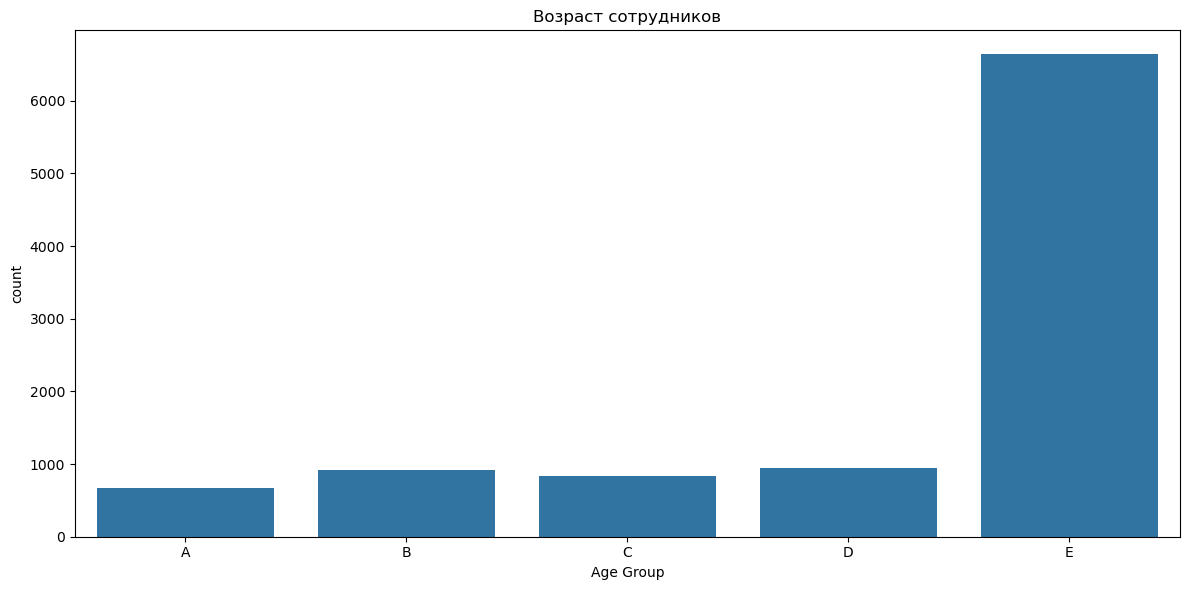

In [25]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Age Group')
plt.title('Возраст сотрудников')
plt.tight_layout()
plt.show()

In [26]:
df.to_csv("Data_for_dash_board.csv", index=False)

- Группа А(от 18 до 25 лет)
- Группа B(от 26 до 35 лет)
- Группа C(от 36 до 45 лет)
- Группа D(от 46 до 55 лет)
- Группа E(от 56 до 100 лет)
  Как мы видим группа E превосходит численностью.

C:\Users\User\AppData\Local\Temp\ipykernel_2624\1247770077.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=top_10_job_data, x="Job Title", y="Age Group", palette="viridis", ci=None)
C:\Users\User\AppData\Local\Temp\ipykernel_2624\1247770077.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_job_data, x="Job Title", y="Age Group", palette="viridis", ci=None)


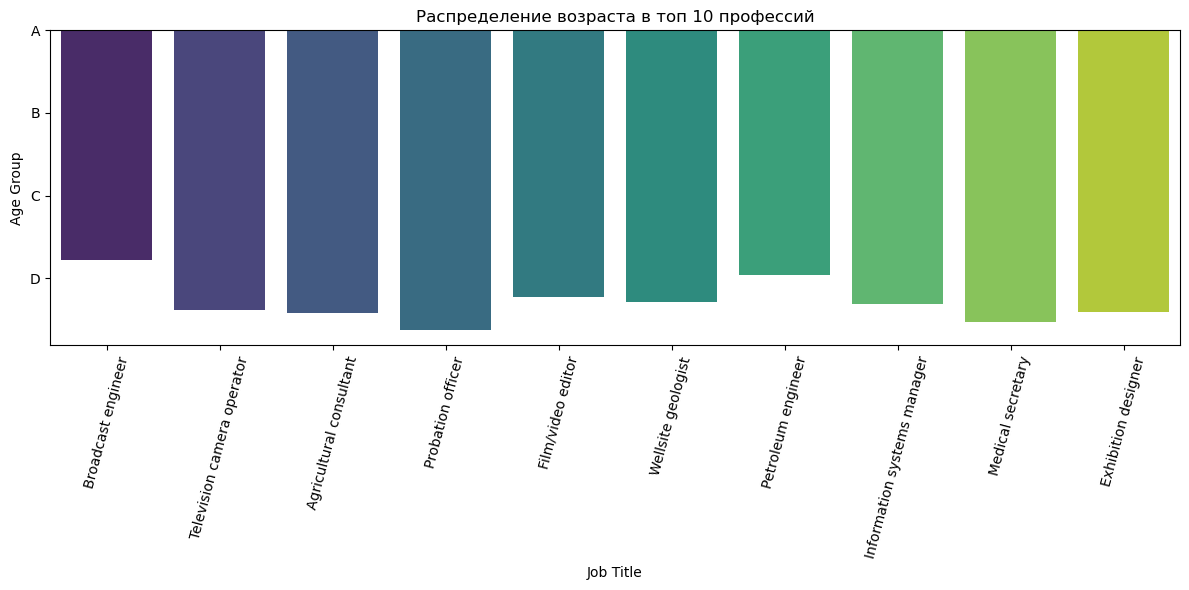

In [27]:
top_10_jobs = df["Job Title"].value_counts().head(10).index
top_10_job_data = df[df["Job Title"].isin(top_10_jobs)]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_job_data, x="Job Title", y="Age Group", palette="viridis", ci=None)
plt.title("Распределение возраста в топ 10 профессий")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [30]:
df.head()

,Index,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title,Age,Age Group,Job Category,Right Age
0,1,Sara,Mcguire,Female,tsharp@example.net,(971)643-6089x9160,2021-08-17,"Editor, commissioning",4,E,design,57.643875
1,2,Alisha,Hebert,Male,vincentgarrett@example.net,+1-114-355-1841x78347,1969-06-28,Broadcast engineer,56,E,engineer,56.000000
2,3,Gwendolyn,Sheppard,Male,mercadojonathan@example.com,9017807728,2015-09-25,Industrial buyer,10,E,consultant_sales,57.091603
3,4,Kristine,Mccann,Female,lindsay55@example.com,+1-607-333-9911x59088,1978-07-27,Multimedia specialist,47,D,tech,47.000000
4,5,Bobby,Pittman,Female,blevinsmorgan@example.com,3739847538,1989-11-17,Planning and development surveyor,36,C,engineer,36.000000


In [28]:
df['Right Age'] = df['Right Age'].astype(int)


приводим возраст к целому числу

# Кластеризация

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder


импорт библиотек

In [102]:
job_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
job_encoded = job_encoder.fit_transform(df[['Job Category']])


 Создаем One-Hot признаки


In [103]:
job_columns = [f"job_{cat}" for cat in job_encoder.categories_[0]]


получаем название колонок

In [104]:
features = np.hstack([
    df[['Right Age']].values,  
    df[['Sex']].values,
    job_encoded
])

features_df = pd.DataFrame(
    np.hstack([df[['Right Age', 'Sex']].values, job_encoded]),
    columns=['Right Age', 'Sex'] + job_columns
)

print(f"Всего признаков: {features.shape[1]}")

Всего признаков: 19


In [147]:
features_df.head()

,Right Age,Sex,job_administration,job_agriculture_environment,job_aviation,job_consultant_sales,job_design,job_education,job_emergency_security,job_engineer,job_finance_legal,job_healthcare,job_library_heritage,job_manager,job_other,job_planning,job_science_research,job_social,job_tech
0,57.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,56.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,57.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,36.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


сбор всех признаков

In [105]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

маштабирование данных 

In [106]:
age_weight = 10
X_scaled_weighted = X_scaled.copy()
X_scaled_weighted[:, 0] = X_scaled[:, 0]

X_scaled = X_scaled_weighted 

Кластеризация K-Means,Agglomerative,DBSCAN

In [107]:
clustering_results = {}
metrics = {}
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clustering_results['K-Means'] = kmeans.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=3)
clustering_results['Agglomerative'] = agglo.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
clustering_results['DBSCAN'] = dbscan.fit_predict(X_scaled)

 

In [108]:
for name, labels in clustering_results.items():
    if len(set(labels)) > 1:   
        metrics[name] = {
            'Silhouette': silhouette_score(X_scaled, labels),
            'Calinski-Harabasz': calinski_harabasz_score(X_scaled, labels),
            'Davies-Bouldin': davies_bouldin_score(X_scaled, labels)
        }

metrics_df = pd.DataFrame(metrics).T
print("\nМЕТРИКИ КЛАСТЕРИЗАЦИИ:")
print(metrics_df.round(4))

 
best_method = metrics_df['Silhouette'].idxmax()
 
 


МЕТРИКИ КЛАСТЕРИЗАЦИИ:
               Silhouette  Calinski-Harabasz  Davies-Bouldin
K-Means            0.1001           686.1796          1.9647
Agglomerative      0.1052           690.4977          1.8001
DBSCAN             0.5493          3581.4503          0.9900


Лучший метод K-Means

вывод всех метрик для кластеров

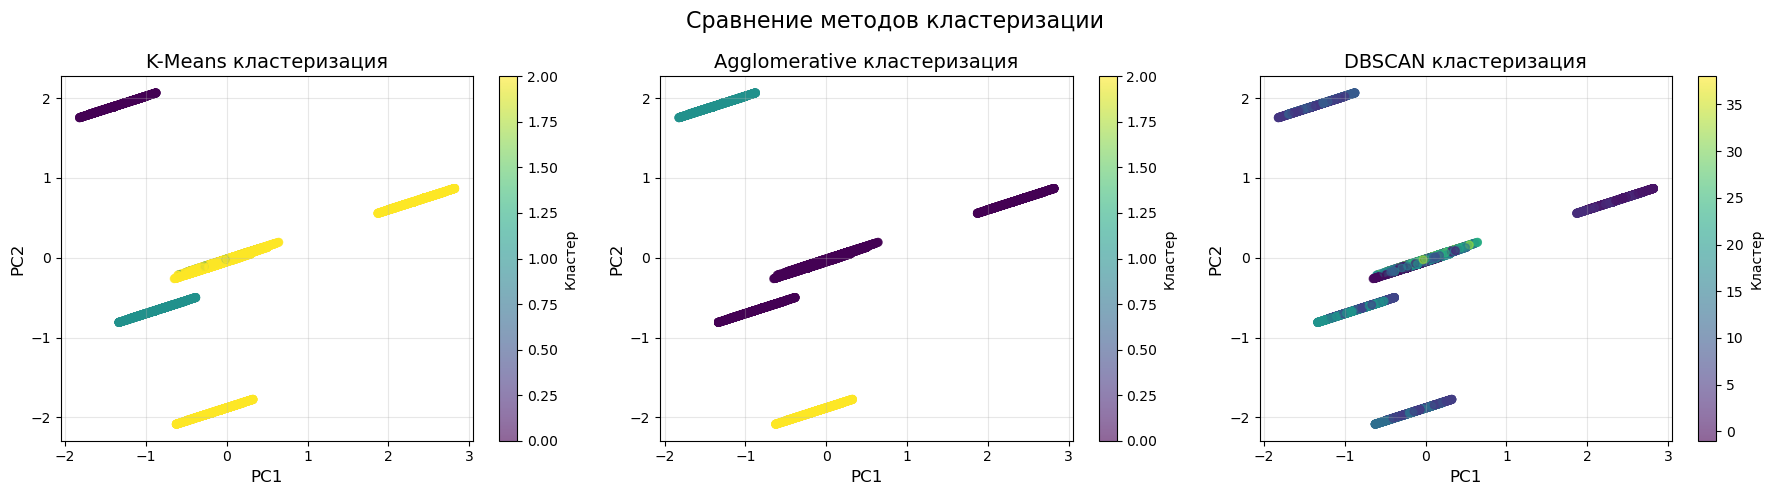

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pca = PCA(n_components=2)  
X_pca = pca.fit_transform(X_scaled_weighted)
for ax, (name, labels) in zip(axes, clustering_results.items()):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, s=30)
    ax.set_title(f'{name} кластеризация', fontsize=14)
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)
    plt.colorbar(scatter, ax=ax, label='Кластер')
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение методов кластеризации', fontsize=16)
plt.tight_layout()
plt.show()

вывод кластеров графический видем 3 четко сформированных группы

In [110]:
df['Cluster'] = clustering_results['K-Means']
cluster_stats = df.groupby('Cluster').agg({
    'Right Age': ['mean', 'std', 'min', 'max', 'count'],
    'Sex': 'mean',
    'Job Category': lambda x: x.value_counts().index[0],  # Самая частая профессия
}).round(2)

cluster_stats.columns = ['Ср.возраст', 'Стд.возраст', 'Мин.возраст', 
                         'Макс.возраст', 'Кол-во', 'Доля женщин', 'Топ-профессия']
print(cluster_stats)


         Ср.возраст  Стд.возраст  Мин.возраст  Макс.возраст  Кол-во  \
Cluster                                                               
0             57.78        19.70           19            98    1406   
1             58.27        19.57           19            98    1402   
2             57.18        19.50           19            98    7192   

         Доля женщин   Топ-профессия  
Cluster                               
0               0.50      healthcare  
1               0.53           other  
2               0.50  administration  


статистика по кластерам

In [111]:
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    
    print(f"\n КЛАСТЕР {cluster} (n={len(cluster_data)} чел., {len(cluster_data)/len(df)*100:.1f}%)")
    print(f"   Возрасттттт: {cluster_data['Right Age'].min():.0f}-{cluster_data['Right Age'].max():.0f} (ср.{cluster_data['Right Age'].mean():.1f})")
    print(f"   Пол: {cluster_data['Sex'].mean()*100:.1f}% женщин")
    print("   ТОП ПРОФЕССИЙ:")
    top5 = cluster_data['Job Category'].value_counts().head(10)
    for job, count in top5.items():
        pct = count/len(cluster_data)*100
        print(f"      {job}: {count} чел. ({pct:.1f}%)")


 КЛАСТЕР 0 (n=1406 чел., 14.1%)
   Возрасттттт: 19-98 (ср.57.8)
   Пол: 50.4% женщин
   ТОП ПРОФЕССИЙ:
      healthcare: 1406 чел. (100.0%)

 КЛАСТЕР 1 (n=1402 чел., 14.0%)
   Возрасттттт: 19-98 (ср.58.3)
   Пол: 52.6% женщин
   ТОП ПРОФЕССИЙ:
      other: 1324 чел. (94.4%)
      aviation: 46 чел. (3.3%)
      emergency_security: 32 чел. (2.3%)

 КЛАСТЕР 2 (n=7192 чел., 71.9%)
   Возрасттттт: 19-98 (ср.57.2)
   Пол: 50.4% женщин
   ТОП ПРОФЕССИЙ:
      administration: 1383 чел. (19.2%)
      engineer: 1353 чел. (18.8%)
      design: 958 чел. (13.3%)
      manager: 799 чел. (11.1%)
      tech: 714 чел. (9.9%)
      consultant_sales: 377 чел. (5.2%)
      finance_legal: 347 чел. (4.8%)
      education: 329 чел. (4.6%)
      science_research: 306 чел. (4.3%)
      planning: 237 чел. (3.3%)


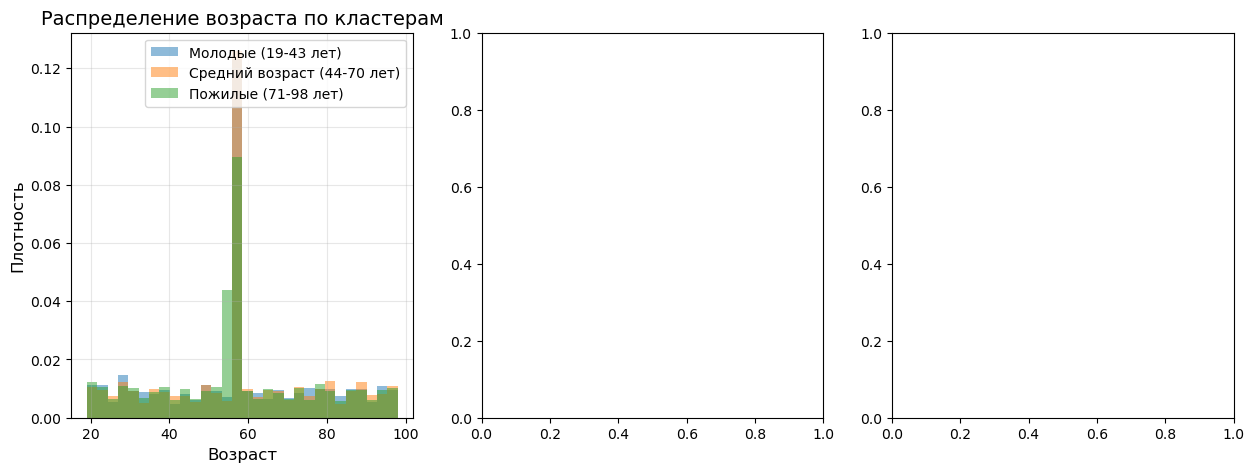

In [112]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plot_df = pd.DataFrame({
    'Age': df['Right Age'],
    'Cluster': clustering_results['K-Means'].astype(str) 
})

cluster_names = {
    '0': 'Молодые (19-43 лет)',
    '1': 'Средний возраст (44-70 лет)', 
    '2': 'Пожилые (71-98 лет)'
}
plot_df['Cluster_Name'] = plot_df['Cluster'].map(cluster_names)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

 
ax1 = axes[0]
for cluster in ['0', '1', '2']:
    cluster_data = plot_df[plot_df['Cluster'] == cluster]['Age']
    ax1.hist(cluster_data, bins=30, alpha=0.5, label=cluster_names[cluster], density=True)
ax1.set_xlabel('Возраст', fontsize=12)
ax1.set_ylabel('Плотность', fontsize=12)
ax1.set_title('Распределение возраста по кластерам', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

 

детальный анализ по профессиям

Топ-профессии более менее одинаковы во всех возрастных группах!
   • healthcare стабильно в топе 
   • administration всегда 2 место 
   • engineer немного падает с возрастом 
   • design стабильно 
ВЫВОД: Люди не меняют профессию кардинально с возрастом!
однако большая часть здравоохранения находиться в более взрослых людей, а у более молодых это инжинерные специальности 

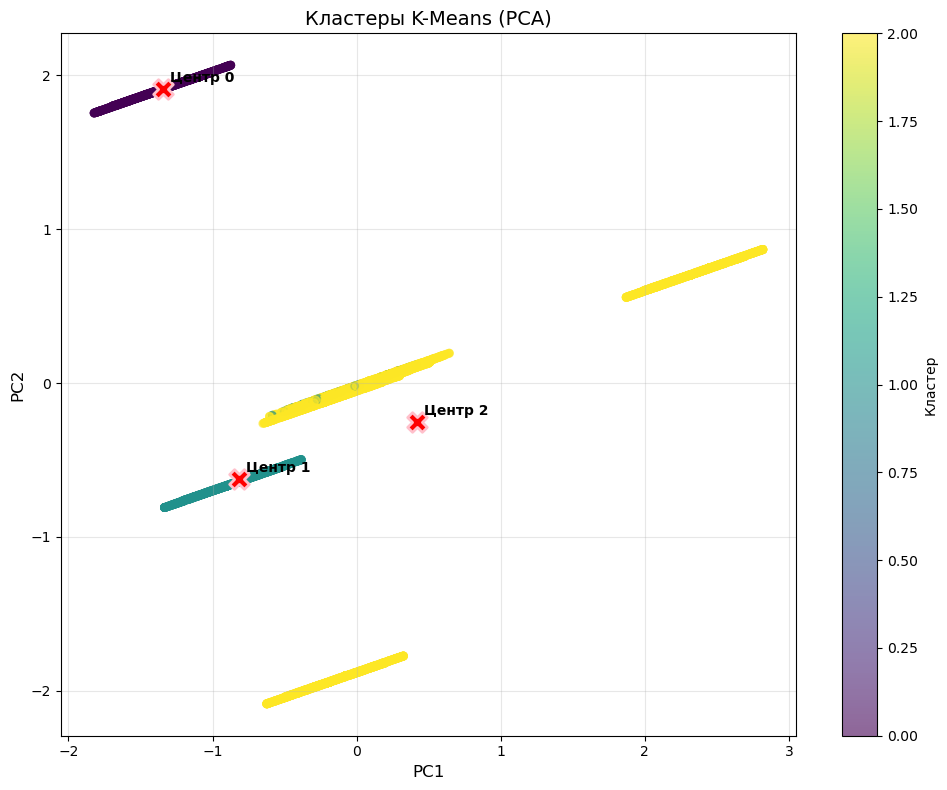

In [113]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df['Cluster'], cmap='viridis', alpha=0.6, s=30)
plt.title('Кластеры K-Means (PCA)', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)

for cluster in sorted(df['Cluster'].unique()):
    center = X_pca[df['Cluster'] == cluster].mean(axis=0)
    plt.scatter(center[0], center[1], 
               c='red', marker='X', s=200, edgecolors='pink', linewidth=2)
    plt.annotate(f'Центр {cluster}', center, 
                fontsize=10, weight='bold',
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()
 

кластеры с центрами 

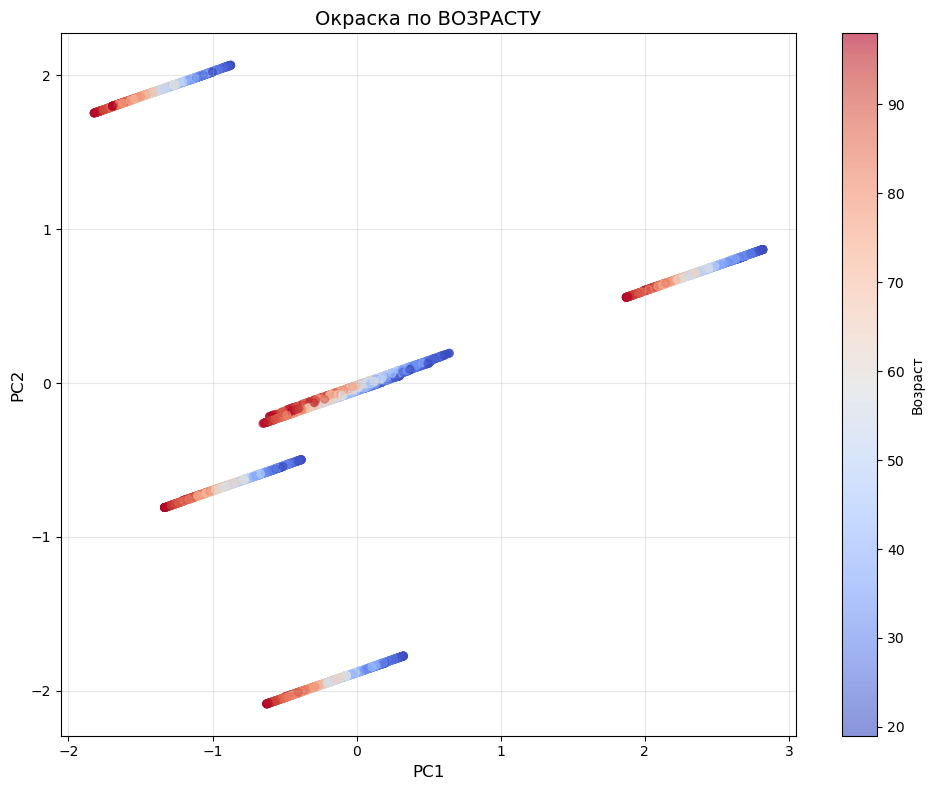

In [114]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df['Right Age'], cmap='coolwarm', alpha=0.6, s=30)
plt.title('Окраска по ВОЗРАСТУ', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.colorbar(scatter, label='Возраст')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

окраска по возрасту мы видим что возраст во всех кластерах нормально распределен 

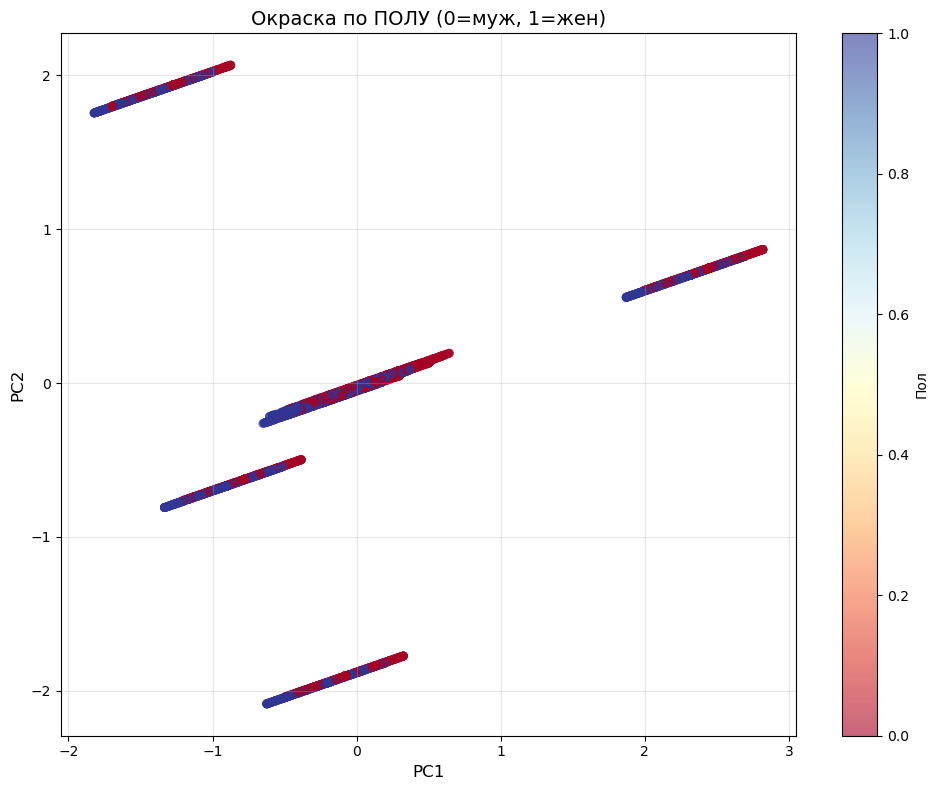

In [115]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df['Sex'], cmap='RdYlBu', alpha=0.6, s=30)
plt.title('Окраска по ПОЛУ (0=муж, 1=жен)', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.colorbar(scatter, label='Пол')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

окраска по полу

<Figure size 1000x600 with 0 Axes>

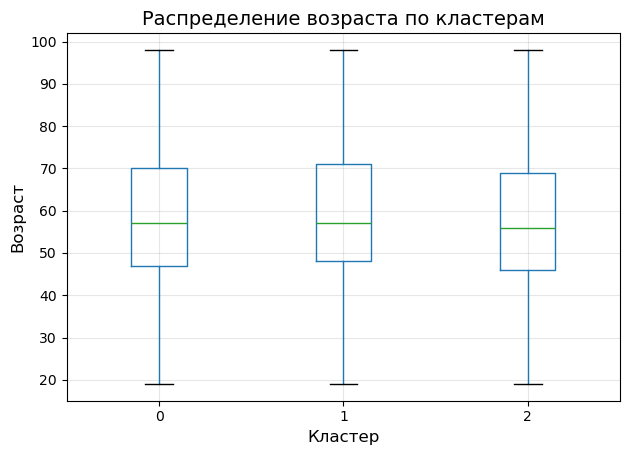

In [116]:
plt.figure(figsize=(10, 6))
df.boxplot(column='Right Age', by='Cluster')
plt.title('Распределение возраста по кластерам', fontsize=14)
plt.suptitle('')  
plt.xlabel('Кластер', fontsize=12)
plt.ylabel('Возраст', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

график распределения возраста по кластера 

<Figure size 1000x600 with 0 Axes>

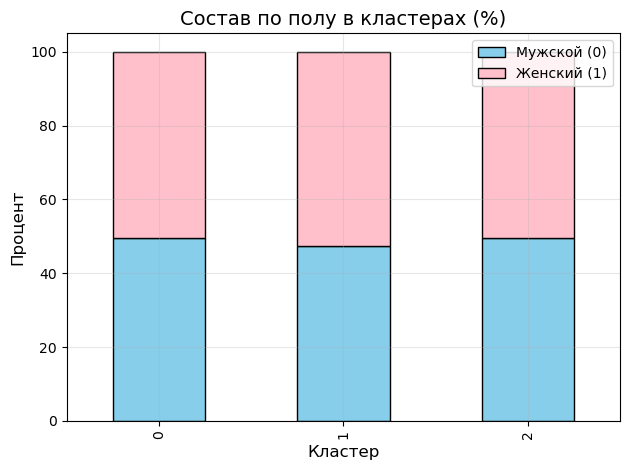

In [117]:
sex_by_cluster = pd.crosstab(df['Cluster'], df['Sex'], normalize='index') * 100
sex_by_cluster.columns = ['Мужской (0)', 'Женский (1)']

plt.figure(figsize=(10, 6))
ax = sex_by_cluster.plot(kind='bar', stacked=True, 
                        color=['skyblue', 'pink'], edgecolor='black')
plt.title('Состав по полу в кластерах (%)', fontsize=14)
plt.xlabel('Кластер', fontsize=12)
plt.ylabel('Процент', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 

процентное соотношение полов к каждом кластере

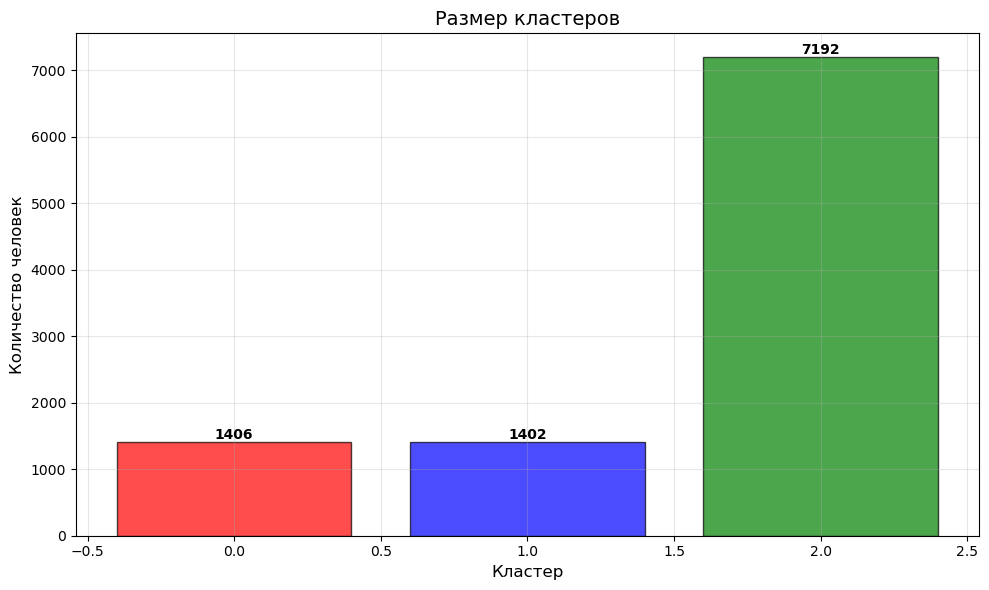

In [118]:
cluster_sizes = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_sizes.index, cluster_sizes.values, 
               color=['red', 'blue', 'green'], alpha=0.7, edgecolor='black')
plt.title('Размер кластеров', fontsize=14)
plt.xlabel('Кластер', fontsize=12)
plt.ylabel('Количество человек', fontsize=12)
plt.grid(True, alpha=0.3)

# Добавляем цифры на столбики
for bar, size in zip(bars, cluster_sizes.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{size}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

количество человек в каждом кластере

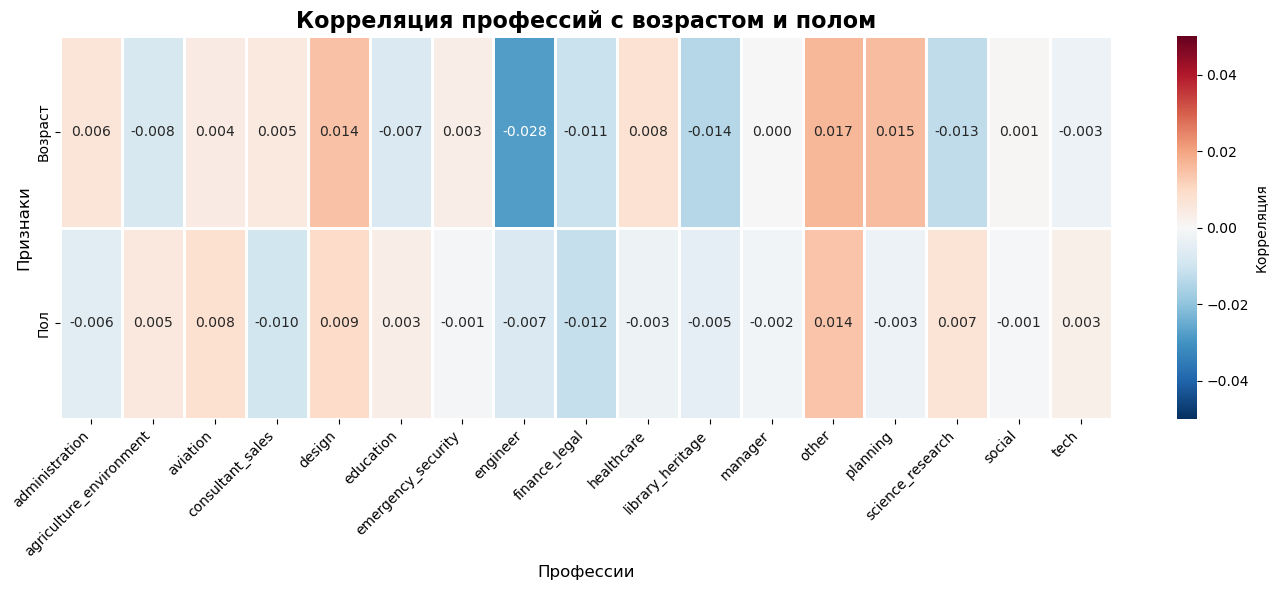

In [98]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

corr_heatmap = pd.DataFrame({
    'Профессия': [p.replace('job_', '') for p in job_columns],
    'Возраст': [correlations.get(p, 0) for p in job_columns],
    'Пол': [sex_correlations.get(p, 0) for p in job_columns]  
})

corr_heatmap.set_index('Профессия', inplace=True)

corr_heatmap = corr_heatmap.T

plt.figure(figsize=(14, 6))

sns.heatmap(corr_heatmap, 
            annot=True,            
            fmt='.3f',            
            cmap='RdBu_r',         
            center=0,              
            vmin=-0.05, vmax=0.05, 
            linewidths=1,          
            cbar_kws={'label': 'Корреляция'},
            annot_kws={'size': 10})

plt.title('Корреляция профессий с возрастом и полом', fontsize=16, fontweight='bold')
plt.xlabel('Профессии', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Ключевые выводы:
Отсутствие демографической предопределенности

Возраст не влияет на выбор профессии

Пол не влияет на выбор профессии

Все профессиональные группы доступны людям независимо от их демографических характеристик

Выделение медицинских работников

Профессия "healthcare" образует отдельный кластер, что свидетельствует о специфике данной профессиональной группы

Медицинские работники, несмотря на равномерное распределение по возрасту и полу, обладают внутренней однородностью, достаточной для выделения в отдельный кластер

Особенности категории "other"

Сборная категория "other" также образует отдельный кластер, что характерно для статистического анализа разнородных групп

Однородность остальных профессий

15 профессиональных категорий (administration, engineer, design, manager и др.) настолько похожи между собой по доступным признакам, что не образуют отдельных кластеров

Это может указывать на схожесть представителей этих профессий по социально-демографическим характеристикам

In [123]:
df["Job Title"].value_counts()

Job Title
Film/video editor           30
Wellsite geologist          28
Medical secretary           28
Exhibition designer         27
Probation officer           27
                            ..
Waste management officer     7
Press sub                    7
Chief Financial Officer      5
Holiday representative       5
Theatre director             5
Name: count, Length: 639, dtype: int64

# Классификация

In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [126]:
le = LabelEncoder()
df['Job_Category_Encoded'] = le.fit_transform(df['Job Category'])

job_categories = dict(zip(le.transform(le.classes_), le.classes_))
print("Кодировка профессий:")
for code, cat in sorted(job_categories.items()):
    print(f"{code}: {cat}")

features = ['Right Age', 'Sex', 'Job_Category_Encoded']
X = df[features].copy()
y = df['Cluster'].copy()


Кодировка профессий:
0: administration
1: agriculture_environment
2: aviation
3: consultant_sales
4: design
5: education
6: emergency_security
7: engineer
8: finance_legal
9: healthcare
10: library_heritage
11: manager
12: other
13: planning
14: science_research
15: social
16: tech


In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  
)

In [132]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

In [133]:
models = {
    'Логистическая регрессия': LogisticRegression(max_iter=1000, random_state=42),
    'Дерево решений': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

In [146]:
results = {}
predictions = {}
for name, model in models.items():
    print(f"{name}")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    accuracy = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred
    }
    print(f"\n Точность на тесте: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Медики', 'Other', 'Остальные']))


Логистическая регрессия

 Точность на тесте: 0.6497
              precision    recall  f1-score   support

      Медики       0.00      0.00      0.00       422
       Other       0.00      0.00      0.00       420
   Остальные       0.70      0.90      0.79      2158

    accuracy                           0.65      3000
   macro avg       0.23      0.30      0.26      3000
weighted avg       0.50      0.65      0.57      3000

Дерево решений

 Точность на тесте: 1.0000
              precision    recall  f1-score   support

      Медики       1.00      1.00      1.00       422
       Other       1.00      1.00      1.00       420
   Остальные       1.00      1.00      1.00      2158

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Random Forest

 Точность на тесте: 0.9977
              precision    recall  f1-score   support

      Медики       1.00      1.00      1.00   

Кластеры, полученные на первом этапе, стали целевой переменной для классификации. Я обучила модель предсказывать эти кластеры по признакам пользователя. 
Теперь для любого нового человека  можно автоматически определить, 
к какой группе он относится — к медикам, к категории 'other' или к остальным профессиям.

ссылка на github

https://github.com/GaliaskarovaGulshat/ML_Project.git

ссылка на дашборд 

https://datalens.yandex/rptlyesg3i3yb